In [1]:
%load_ext autoreload
%autoreload 2

In [300]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import tifffile as tiff
import numpy as np
import os
from scipy.signal import medfilt
import track_mate_visualisation as tmv
import scienceplots
from matplotlib.collections import LineCollection
import seaborn as sns

In [3]:
plt.style.use(["science", "high-vis", "bright", "no-latex"])

## General:
* Tiff-images are processed as batches in sizes of 2000 tiffs (at least I had to on my laptop)
* Per batch Fiji produces a spots.csv and a edges.csv containing the information of the spoted dust grains and the linked trajectories
* track_mate_visualisation contains a method (tmv.dataprocessing.combine_csv(paths_edges=edges, paths_spots=spots)) to combine these split csvs into one big dataframe 
* It is recommended to further filter short or bad linked trajectories 


In [215]:
min_length = 100
max_sign_changes_x = 2
max_sign_changes_y = 2
std_min_y = 10.0
min_y = 600
fraction_of_y_median = 0.85
median_filter = lambda x: medfilt(x, kernel_size=3)

(<Figure size 800x400 with 2 Axes>, <Axes: xlabel='x (px)', ylabel='y (px)'>)

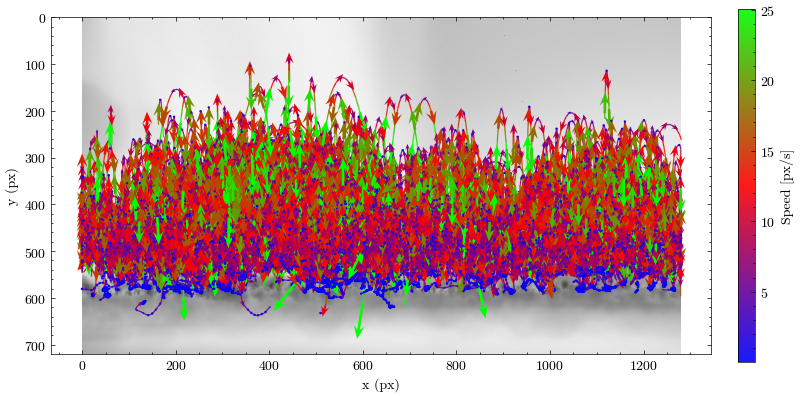

In [270]:
path = Path("/Volumes/Festplatte2/06_10_25/lhc_beamscreen_UV_then_3kV_silica/")
p_tifs = path / "tifs"
tifs = [
    p_tifs / i
    for i in sorted(os.listdir(p_tifs))
    if ".tif" in i and not "absdiff" in i and not "._" in i
    #  and int(i.split("_")[1].replace(".tif", "")) >= 18000
]
edges = sorted(
    [
        path / "results" / i
        for i in os.listdir(path / "results")
        if "edges" in i and ".csv" in i and not "._" in i
    ],
    key=lambda s: str(s).split("_")[1],
)
spots = sorted(
    [
        path / "results" / i
        for i in os.listdir(path / "results")
        if "spots" in i and ".csv" in i and not "._" in i
    ],
    key=lambda s: str(s).split("_")[1],
)

img_id = 0
img = tiff.imread(tifs[0]).astype("float32")
out = tmv.dataprocessing.combine_csv(paths_edges=edges, paths_spots=spots)
df_spots = out["spots"]
df_edges = out["edges"]
y_track_median = np.median(df_edges.y)

out = tmv.dataprocessing.filter_df(
    df_spots=df_spots,
    df_edges=df_edges,
    std_min_y=std_min_y,
    min_y=y_track_median * fraction_of_y_median,
    max_sign_changes_x=max_sign_changes_x,
    max_sign_changes_y=max_sign_changes_y,
    min_length=min_length,
    apply_track_filter=tmv.trajectory_filters.smooth_track,
    # apply_filter=lambda x: medfilt(x, kernel_size=5),
)
df_spots = out["spots"]
df_edges = out["edges"]


fig, ax = plt.subplots(figsize=(8, 4))
tmv.plot.plot(
    spots=df_spots,
    edges=df_edges,
    img_id=img_id,
    img=img,
    fig=fig,
    cmap="brg",
    ax=ax,
)

In [268]:
# ensure unique, positional index
df_e = df_edges.reset_index(drop=True)

g = df_e.groupby("TRACK_ID", sort=False)

idx_vx_min = g["vx"].idxmin()
idx_vx_max = g["vx"].idxmax()
idx_vy_min = g["vy"].idxmin()
idx_vy_max = g["vy"].idxmax()


def extremum(df, idx, col, which):
    ok = idx.dropna().astype(int)
    out = (
        df.loc[ok, ["TRACK_ID", col, "t"]]
        .set_index("TRACK_ID")
        .rename(columns={col: f"{col}_{which}", "t": f"t_{col}_{which}"})
    )
    return out


stats = pd.concat(
    [
        extremum(df_e, idx_vx_min, "vx", "min"),
        extremum(df_e, idx_vx_max, "vx", "max"),
        extremum(df_e, idx_vy_min, "vy", "min"),
        extremum(df_e, idx_vy_max, "vy", "max"),
    ],
    axis=1,
).reset_index()


stats = stats.reset_index()
stats["vx_min_before_vx_max"] = [
    True if row["t_vx_min"] < row["t_vx_max"] else False for ix, row in stats.iterrows()
]
stats["vy_min_before_vy_max"] = [
    True if row["t_vy_min"] < row["t_vy_max"] else False for ix, row in stats.iterrows()
]

array([[<Axes: title={'center': 'max_left_acc'}>]], dtype=object)

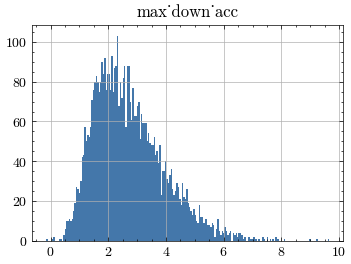

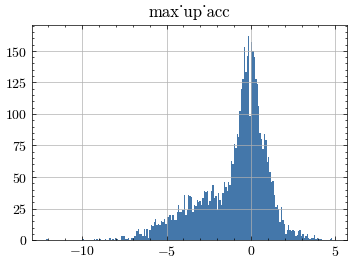

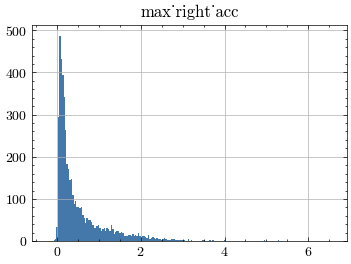

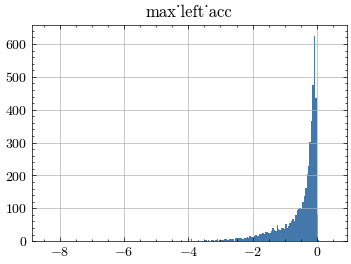

In [277]:
g = df_edges.groupby("TRACK_ID", sort=False)
g.agg(max_down_acc=("ay", "max")).hist(bins=200)
g.agg(max_up_acc=("ay", "min")).hist(bins=200)
g.agg(max_right_acc=("ax", "max")).hist(bins=200)
g.agg(max_left_acc=("ax", "min")).hist(bins=200)

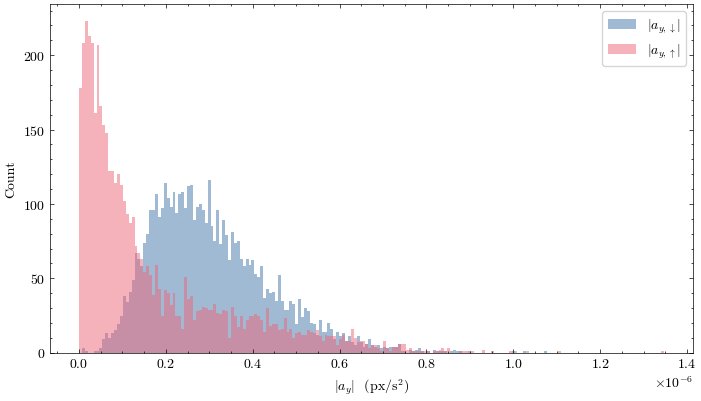

In [296]:
g = df_edges.groupby("TRACK_ID", sort=False)


down = g["ay"].max()  # strongest downward (image coords)
up = g["ay"].min()  # strongest upward

down /= 3000**2  # pixel per sec^2
up /= 3000**2  # pixel per sec^2

down_abs = down.abs().to_numpy()
up_abs = up.abs().to_numpy()

# shared bins from both sets
edges = np.histogram_bin_edges(np.concatenate([down_abs, up_abs]), bins=200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(down_abs, bins=edges, alpha=0.5, label=r"$|a_{y,\downarrow}|$")
ax.hist(up_abs, bins=edges, alpha=0.5, label=r"$|a_{y,\uparrow}|$")
ax.set_xlabel(r"$|a_y|$  (px/s$^2$)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")

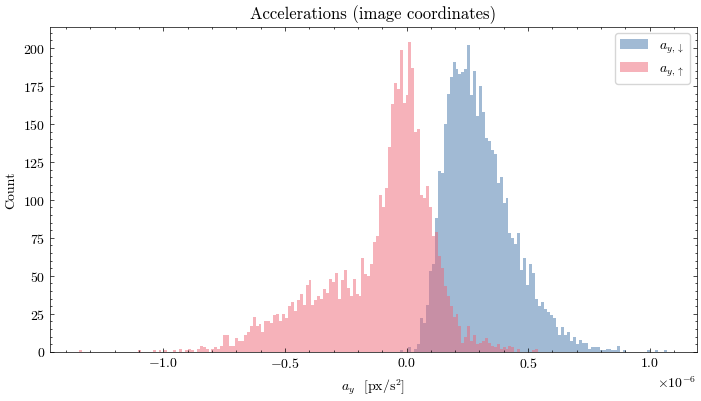

In [348]:
g = df_edges.groupby("TRACK_ID", sort=False)

down = g["ay"].max()  # strongest downward (image coords)
up = g["ay"].min()  # strongest upward

down_abs = down.to_numpy()
up_abs = up.to_numpy()
down /= 3000**2  # pixel per sec^2
up /= 3000**2  # pixel per sec^2
# shared bins from both sets
edges = np.histogram_bin_edges(np.concatenate([down_abs, up_abs]), bins=200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(down_abs, bins=edges, alpha=0.5, label=r"$a_{y,\downarrow}$")
ax.hist(up_abs, bins=edges, alpha=0.5, label=r"$a_{y,\uparrow}$")
ax.set_title("Accelerations (image coordinates)")
ax.set_xlabel(r"$a_y$  [px/s$^2$]")
ax.set_ylabel("Count")
ax.legend(loc="upper right")

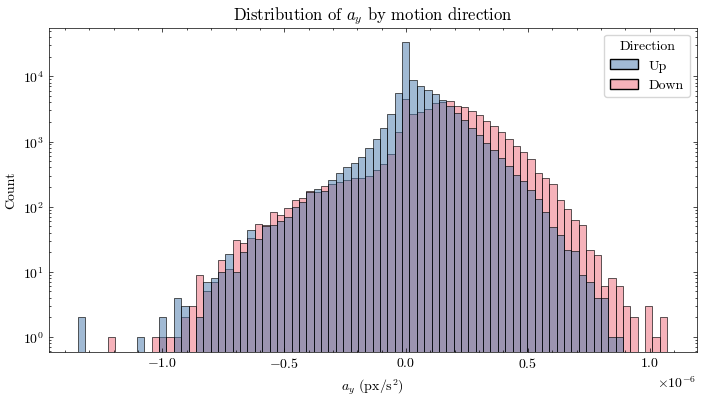

In [341]:
dfh = df_edges.copy()
dfh["ay"] /= 3000**2

dfh["Direction"] = np.where((dfh["vy"] > 0.1), "Down", "Up")


fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=dfh,
    x="ay",
    hue="Direction",  # just two layers: up vs down
    bins=80,
    multiple="layer",  # overlay, not stacked
    common_norm=False,  # keep counts comparable
    alpha=0.5,
    ax=ax,
)
ax.set_xlabel(r"$a_y$ (px/s$^2$)")
ax.set_ylabel("Count")
ax.set_title("Distribution of $a_y$ by motion direction")
ax.set_yscale("log")

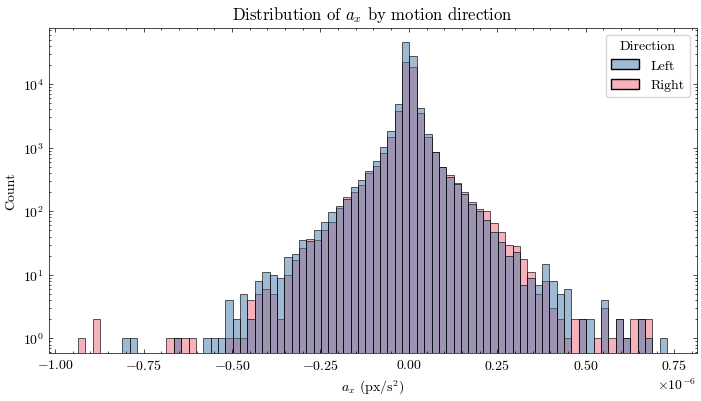

In [342]:
dfh = df_edges.copy()
dfh["ax"] /= 3000**2

dfh["Direction"] = np.where((dfh["vx"] > 0.1), "Right", "Left")


fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=dfh,
    x="ax",
    hue="Direction",  # just two layers: up vs down
    bins=80,
    multiple="layer",  # overlay, not stacked
    common_norm=False,  # keep counts comparable
    alpha=0.5,
    ax=ax,
)
ax.set_xlabel(r"$a_x$ (px/s$^2$)")
ax.set_ylabel("Count")
ax.set_title("Distribution of $a_x$ by motion direction")
ax.set_yscale("log")

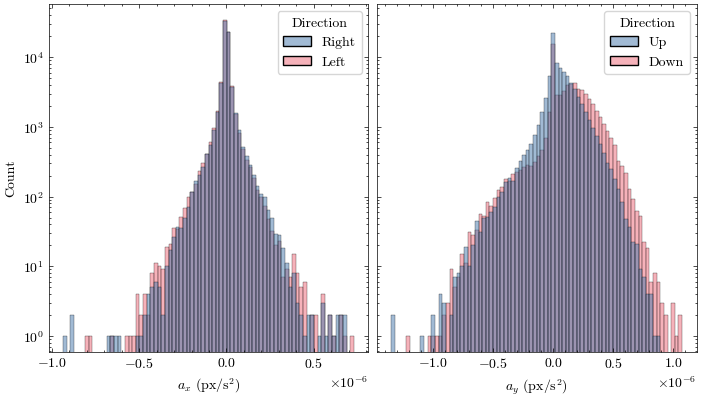

In [347]:
dfh = df_edges.copy()
dfh["ax"] /= 3000**2
dfh["ay"] /= 3000**2

dfh["Direction"] = np.where((dfh["vx"] > 0.0), "Right", "Left")


fig, ax = plt.subplots(figsize=(7, 4), ncols=2, sharey=True)
sns.histplot(
    data=dfh,
    x="ax",
    hue="Direction",  # just two layers: up vs down
    bins=80,
    multiple="layer",  # overlay, not stacked
    common_norm=False,  # keep counts comparable
    alpha=0.5,
    ax=ax[0],
)


dfh["Direction"] = np.where((dfh["vy"] > 0.0), "Down", "Up")

sns.histplot(
    data=dfh,
    x="ay",
    hue="Direction",  # just two layers: up vs down
    bins=80,
    multiple="layer",  # overlay, not stacked
    common_norm=False,  # keep counts comparable
    alpha=0.5,
    ax=ax[1],
)
ax[0].set_xlabel(r"$a_x$ (px/s$^2$)")
ax[1].set_xlabel(r"$a_y$ (px/s$^2$)")
ax[0].set_ylabel("Count")

if False:
    fig.suptitle(r"Distribution of $\vec a$")
    ax[0].set_title(r"$a_x$ (px/s$^2$)")
    ax[1].set_title(r"$a_y$ (px/s$^2$)")
ax[0].set_yscale("log")